In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


In [4]:
image_cut = image[75:175, 0:1890]
image_error_cut = image_error[75:175, 0:1890]

Text(0.5, 0, 'wavelength')

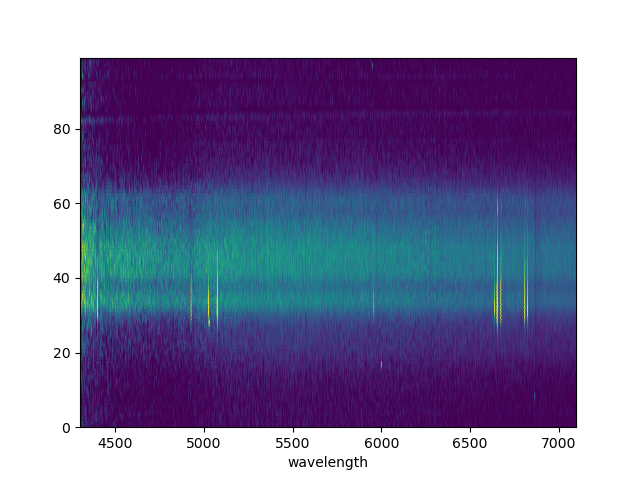

In [5]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

In [6]:
z = 0.01505 
l_HA_z = 6563 * (1+z)
l_HB_z = 4861 * (1+z) 
l_NII_z = 6583 * (1+z)
l_SII_z = 6717 * (1+z)
l_OIII_z = 5007 * (1+z)

l_HA = 6654
l_HB = 4929 
l_NII = 6676
l_SII = 6811
l_OIII = 5077

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/PSF/Real_seeing_Mrk553.txt")
sigma = seeing[0] / 2.35

Text(0.5, 1.0, 'H$\\alpha$')

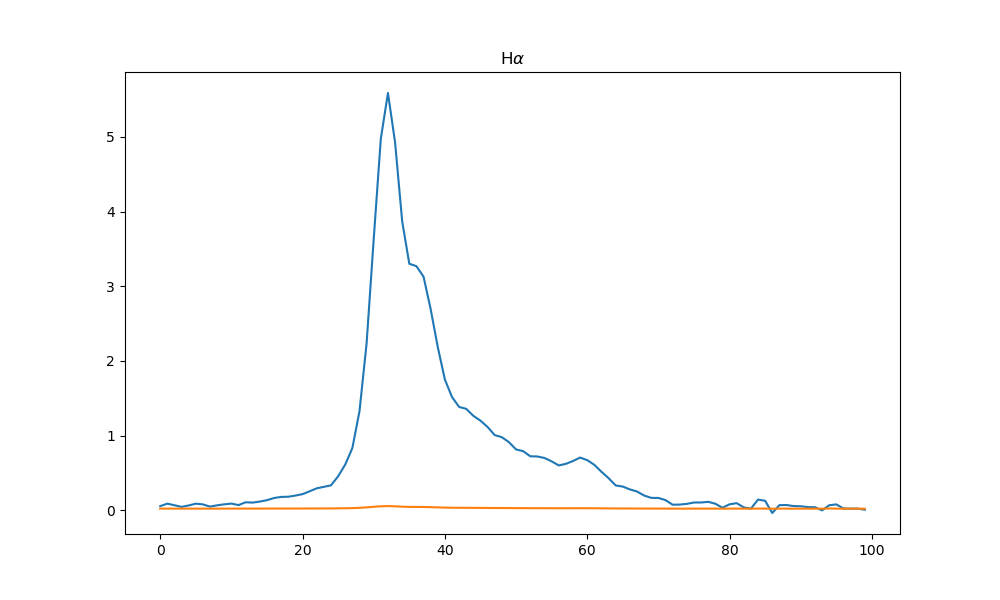

In [7]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [8]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
#def chi_quad(x, y, y_err, params):
#    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, chi, params): #k=number of model parameter, N=number of data points
    return chi + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, chi, params):
        return chi + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, chi2

In [9]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

]   # x_0: posizione da 0 a 100

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 20.176409535882996
differential_evolution step 2: f(x)= 19.961656184617535
differential_evolution step 3: f(x)= 19.961656184617535
differential_evolution step 4: f(x)= 19.961656184617535
differential_evolution step 5: f(x)= 16.752675689197936
differential_evolution step 6: f(x)= 16.476790576656
differential_evolution step 7: f(x)= 16.476790576656
differential_evolution step 8: f(x)= 14.651908492740468
differential_evolution step 9: f(x)= 14.651908492740468
differential_evolution step 10: f(x)= 14.089130270745342
differential_evolution step 11: f(x)= 14.089130270745342
differential_evolution step 12: f(x)= 13.853425007198993
differential_evolution step 13: f(x)= 13.80306234299446
differential_evolution step 14: f(x)= 13.80306234299446
differential_evolution step 15: f(x)= 13.80306234299446
differential_evolution step 16: f(x)= 13.663934025085142
differential_evolution step 17: f(x)= 13.663934025085142
differential_evolution step 18: f(x)= 13.62854439

Optimize parameters with curve fit:
Sérsic 1: I_e=0.2511, r_e=22.9010, n=2.0031, x_0=33.5378
[0.11758637 7.44415574 0.35456219 0.2355912 ]
129.66745686002045
138.0885094915994 0.0 148.08813760397283 4


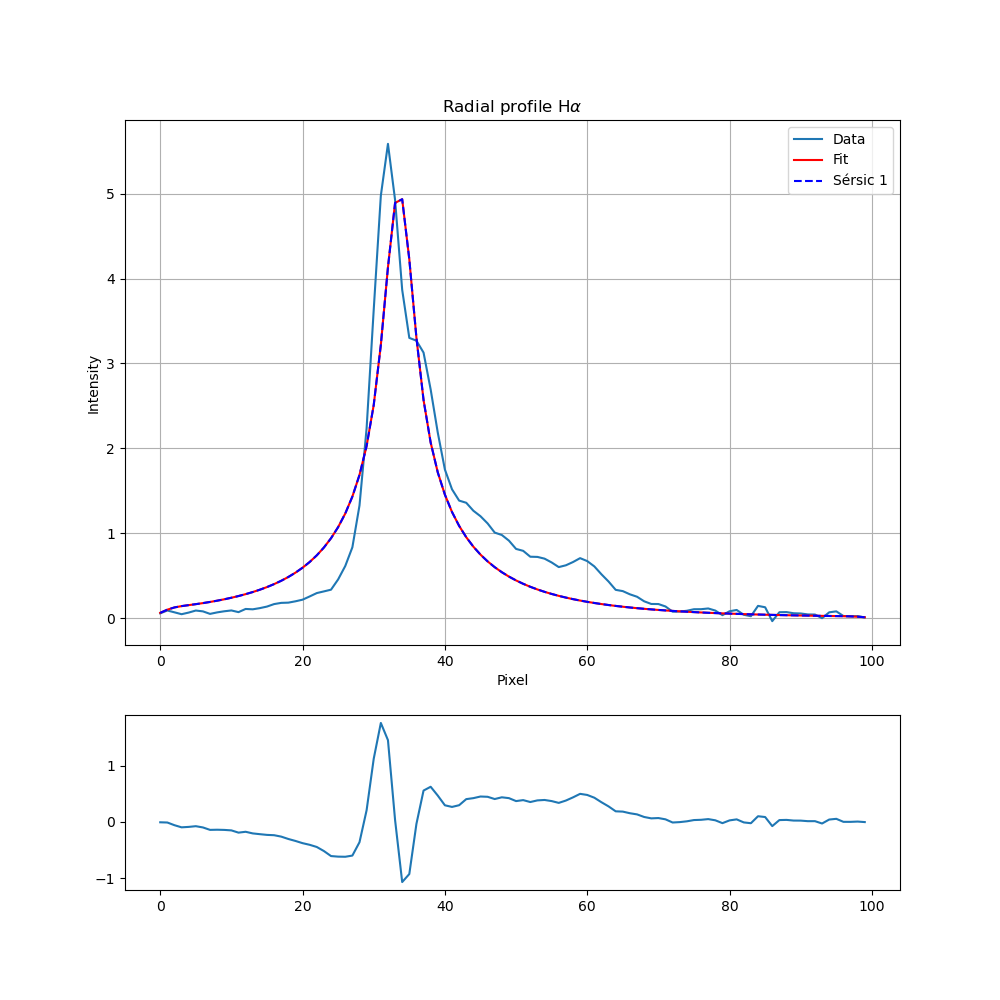

In [11]:
aic = np.zeros(6)
bic = np.zeros(6)
chi_quadr = np.zeros(6)
chi_quadro = np.zeros(6)
red_chi = np.zeros(6)

params_curve_1, covariance_1 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params1,
                                         sigma = radial_profile_error_HA, maxfev = 10000)

print("Optimize parameters with curve fit:")

chi_quadr[0], red_chi[0] = save_params(params_curve_1, covariance_1, radial_profile_HA, radial_profile_error_HA, x_axes, 1, line_name="One", 
                                           output_prefix="fit")

aic[0] = AIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
bic[0] = BIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
print(aic[0], chi_quadro[0], bic[0], len(params_curve_1))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_1', bbox_inches='tight')

In [12]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (30, 40),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 197.78092711045576
differential_evolution step 2: f(x)= 51.46449361305561
differential_evolution step 3: f(x)= 51.46449361305561
differential_evolution step 4: f(x)= 51.46449361305561
differential_evolution step 5: f(x)= 51.46449361305561
differential_evolution step 6: f(x)= 35.8738991270146
differential_evolution step 7: f(x)= 31.37730159375463
differential_evolution step 8: f(x)= 31.37730159375463
differential_evolution step 9: f(x)= 31.37730159375463
differential_evolution step 10: f(x)= 22.043027916306563
differential_evolution step 11: f(x)= 22.043027916306563
differential_evolution step 12: f(x)= 22.043027916306563
differential_evolution step 13: f(x)= 21.447737633611215
differential_evolution step 14: f(x)= 19.45500124795373
differential_evolution step 15: f(x)= 11.875930559824704
differential_evolution step 16: f(x)= 11.875930559824704
differential_evolution step 17: f(x)= 11.875930559824704
differential_evolution step 18: f(x)= 11.875930559

Optimize parameters with curve fit:
Sérsic 1: I_e=2.3667, r_e=3.1485, n=0.4733, x_0=32.8434
Sérsic 2: I_e=0.3632, r_e=19.0479, n=0.8652, x_0=42.4209
[0.32514832 0.2614933  0.10939836 0.11290921 0.07649648 2.05298062
 0.12352779 0.91109913]
26.68588764307365
44.26830522549123 26.68588764307365 63.52724913097838 8


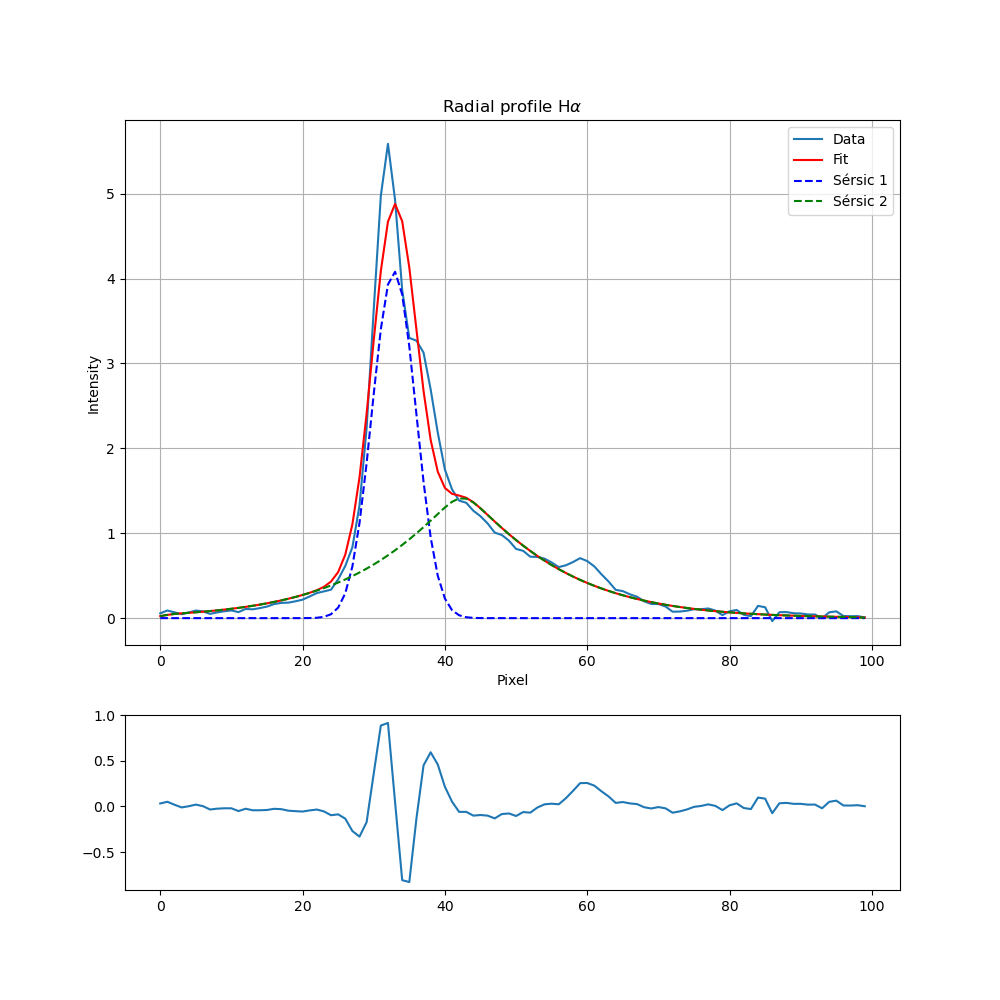

In [13]:
# Plots:
params_curve_2, covariance_2 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params2, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[1], red_chi[1] = save_params(params_curve_2, covariance_2, radial_profile_HA, radial_profile_error_HA,
    x_axes, 2, line_name="Two", output_prefix="fit")

aic[1] = AIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
bic[1] = BIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
print(aic[1], chi_quadr[1], bic[1], len(params_curve_2))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_2', bbox_inches='tight')

In [14]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (30, 40),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 50),

]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 5130.0926139113635
differential_evolution step 2: f(x)= 940.3711840501546
differential_evolution step 3: f(x)= 338.8734782741184
differential_evolution step 4: f(x)= 338.8734782741184
differential_evolution step 5: f(x)= 140.965769952651
differential_evolution step 6: f(x)= 140.965769952651
differential_evolution step 7: f(x)= 140.965769952651
differential_evolution step 8: f(x)= 140.965769952651
differential_evolution step 9: f(x)= 140.965769952651
differential_evolution step 10: f(x)= 140.965769952651
differential_evolution step 11: f(x)= 127.0165984436254
differential_evolution step 12: f(x)= 18.803389732502986
differential_evolution step 13: f(x)= 18.803389732502986
differential_evolution step 14: f(x)= 18.803389732502986
differential_evolution step 15: f(x)= 18.803389732502986
differential_evolution step 16: f(x)= 18.803389732502986
differential_evolution step 17: f(x)= 18.803389732502986
differential_evolution step 18: f(x)= 18.803389732502986

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15272\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15272\2169801097.py:9: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.7749, r_e=1.9932, n=0.9523, x_0=31.7230
Sérsic 2: I_e=0.3903, r_e=5.1716, n=1.2889, x_0=36.7134
Sérsic 3: I_e=0.3780, r_e=18.5831, n=0.6423, x_0=44.6353
[0.53411878 0.31416374 0.25789596 0.06483552 0.29549732 3.45038858
 0.5538741  0.18503733 0.04278312 0.63351417 0.05330303 0.96338421]
4.110113960774488
31.696320857326214 4.110113960774488 59.37215619263159 12


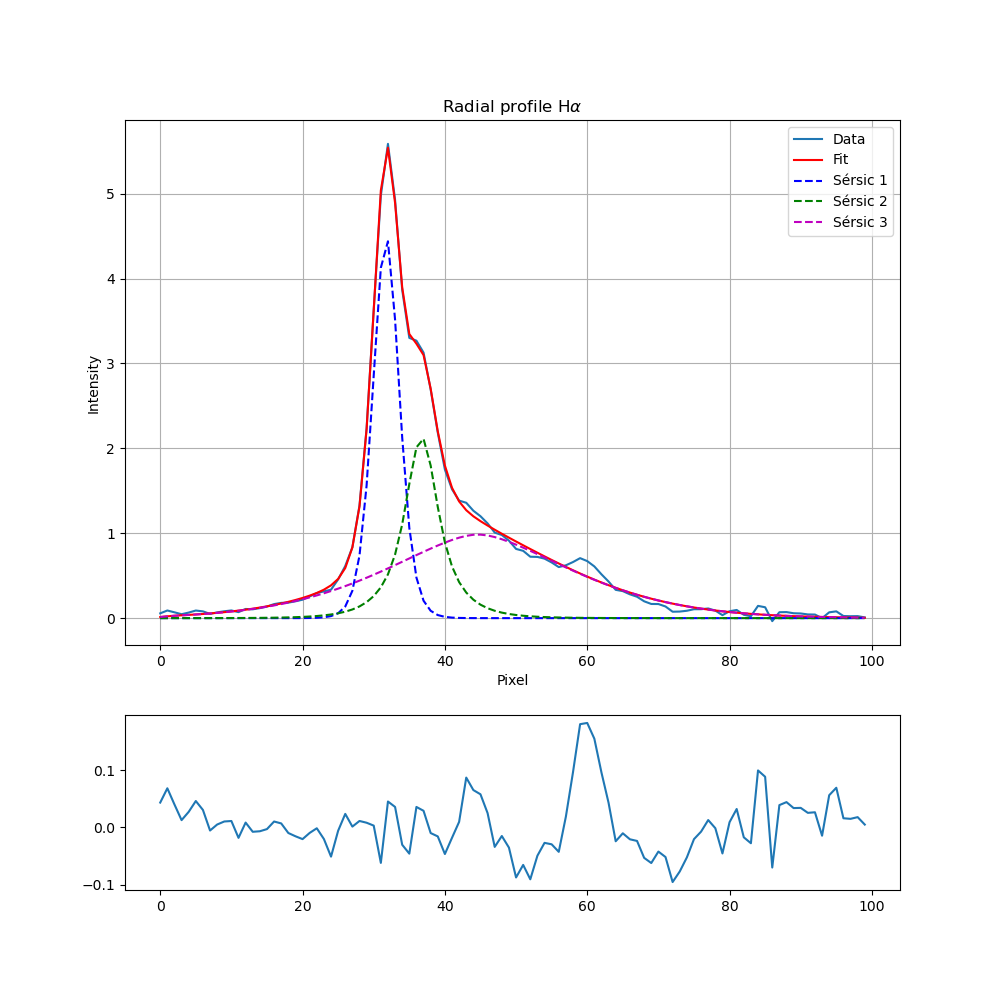

In [15]:
# Plots:
params_curve_3, covariance_3 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params3, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[2], red_chi[2] = save_params(params_curve_3, covariance_3, radial_profile_HA, radial_profile_error_HA,x_axes, 3,  
                                       line_name="Three", output_prefix="fit")

aic[2] = AIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
bic[2] = BIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
print(aic[2], chi_quadr[2], bic[2], len(params_curve_3))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_3', bbox_inches='tight')

In [16]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (30, 40),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 65)

]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 4112.290264546711
differential_evolution step 2: f(x)= 4112.290264546711
differential_evolution step 3: f(x)= 4112.290264546711
differential_evolution step 4: f(x)= 4112.290264546711
differential_evolution step 5: f(x)= 3196.231140421024
differential_evolution step 6: f(x)= 3196.231140421024
differential_evolution step 7: f(x)= 3196.231140421024
differential_evolution step 8: f(x)= 3196.231140421024
differential_evolution step 9: f(x)= 1385.0634268754543
differential_evolution step 10: f(x)= 662.0076199329941
differential_evolution step 11: f(x)= 662.0076199329941
differential_evolution step 12: f(x)= 662.0076199329941
differential_evolution step 13: f(x)= 377.0611288473487
differential_evolution step 14: f(x)= 377.0611288473487
differential_evolution step 15: f(x)= 183.74292386950214
differential_evolution step 16: f(x)= 183.74292386950214
differential_evolution step 17: f(x)= 183.74292386950214
differential_evolution step 18: f(x)= 176.98101678612

Optimize parameters with curve fit:
Sérsic 1: I_e=1.6539, r_e=2.1946, n=1.0050, x_0=31.7713
Sérsic 2: I_e=0.1801, r_e=8.7819, n=1.8798, x_0=36.8156
Sérsic 3: I_e=0.2334, r_e=20.8014, n=0.9210, x_0=44.2152
Sérsic 4: I_e=0.0918, r_e=4.1574, n=0.9214, x_0=59.6504
[0.21909158 0.17319714 0.11374945 0.035347   0.09866201 5.55618542
 0.378481   0.09042228 0.05990429 1.00191582 0.0802175  0.82696562
 0.05763715 2.27753916 0.47469767 0.24071734]
1.453386807076716
40.0076036745466 1.453386807076716 75.13610978288618 16


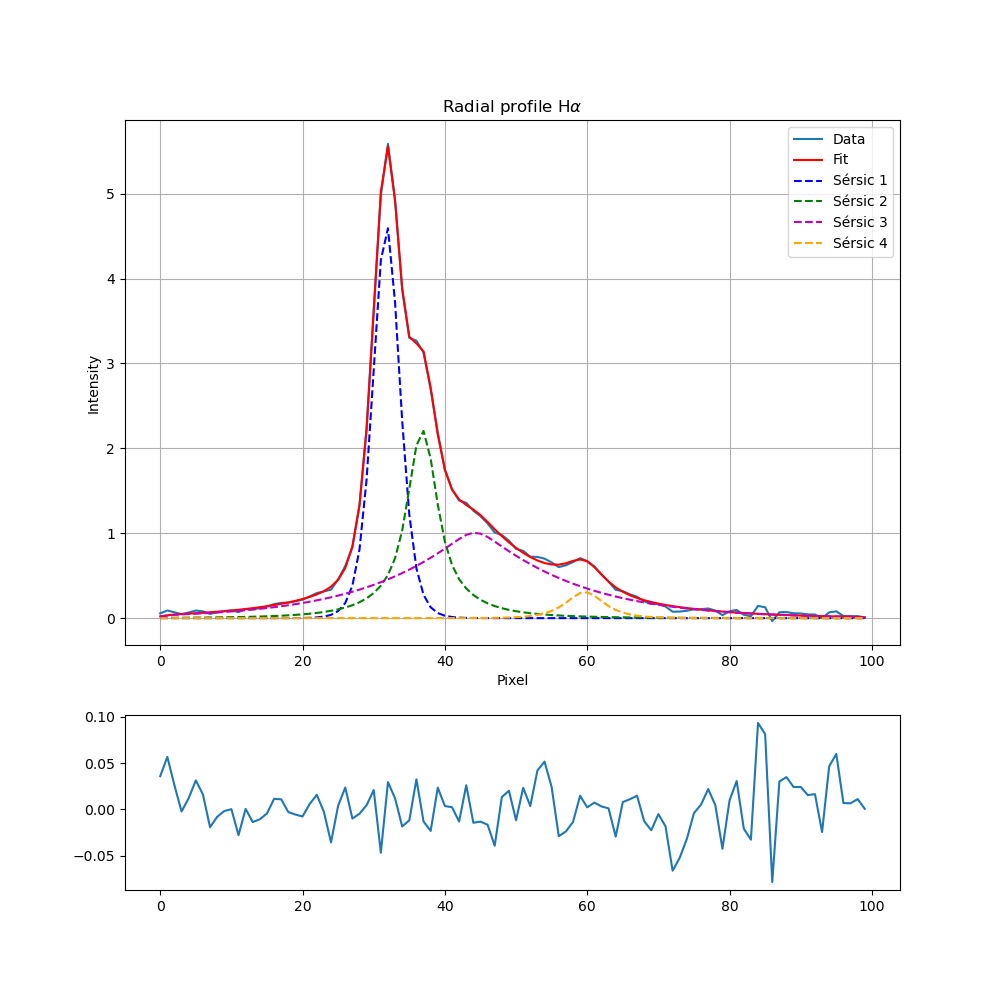

In [17]:
# Plots:
params_curve_4, covariance_4 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params4, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[3], red_chi[3] = save_params(params_curve_4, covariance_4, radial_profile_HA, radial_profile_error_HA, x_axes, 4, line_name="Four", output_prefix="fit")

aic[3] = AIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
bic[3] = BIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
print(aic[3], chi_quadr[3], bic[3], len(params_curve_4))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_4', bbox_inches='tight')

In [18]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (30, 40),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 65),
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 30793.191717349764
differential_evolution step 2: f(x)= 29059.009142498922
differential_evolution step 3: f(x)= 5623.401132899983
differential_evolution step 4: f(x)= 4515.779050438875
differential_evolution step 5: f(x)= 4515.779050438875
differential_evolution step 6: f(x)= 4515.779050438875
differential_evolution step 7: f(x)= 4515.779050438875
differential_evolution step 8: f(x)= 4515.779050438875
differential_evolution step 9: f(x)= 4515.779050438875
differential_evolution step 10: f(x)= 4515.779050438875
differential_evolution step 11: f(x)= 4515.779050438875
differential_evolution step 12: f(x)= 4515.779050438875
differential_evolution step 13: f(x)= 4515.779050438875
differential_evolution step 14: f(x)= 745.0624646135395
differential_evolution step 15: f(x)= 652.4168137123894
differential_evolution step 16: f(x)= 652.4168137123894
differential_evolution step 17: f(x)= 652.4168137123894
differential_evolution step 18: f(x)= 652.4168137123894

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15272\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15272\4010452568.py:11: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.7126, r_e=2.1458, n=0.9838, x_0=31.7678
Sérsic 2: I_e=0.4597, r_e=3.2484, n=1.2318, x_0=36.8027
Sérsic 3: I_e=0.3700, r_e=13.3742, n=0.5509, x_0=41.7536
Sérsic 4: I_e=0.0619, r_e=6.5531, n=1.2244, x_0=59.9460
Sérsic 5: I_e=0.0111, r_e=128.0955, n=2.1569, x_0=43.5063
[3.00333431e-01 2.48289881e-01 1.49881367e-01 3.73890099e-02
 6.85555203e-01 4.27004573e+00 1.07378030e+00 8.71110132e-02
 1.13396322e-01 2.48480163e+00 1.69746584e-01 2.22458735e+00
 3.75880631e-02 5.19140585e+00 4.49350199e-01 2.58354160e-01
 4.76564826e-02 4.30218744e+02 2.09646680e+00 1.14438005e+00]
1.206348315933404
51.83925970833847 1.206348315933404 93.30975203569525 20


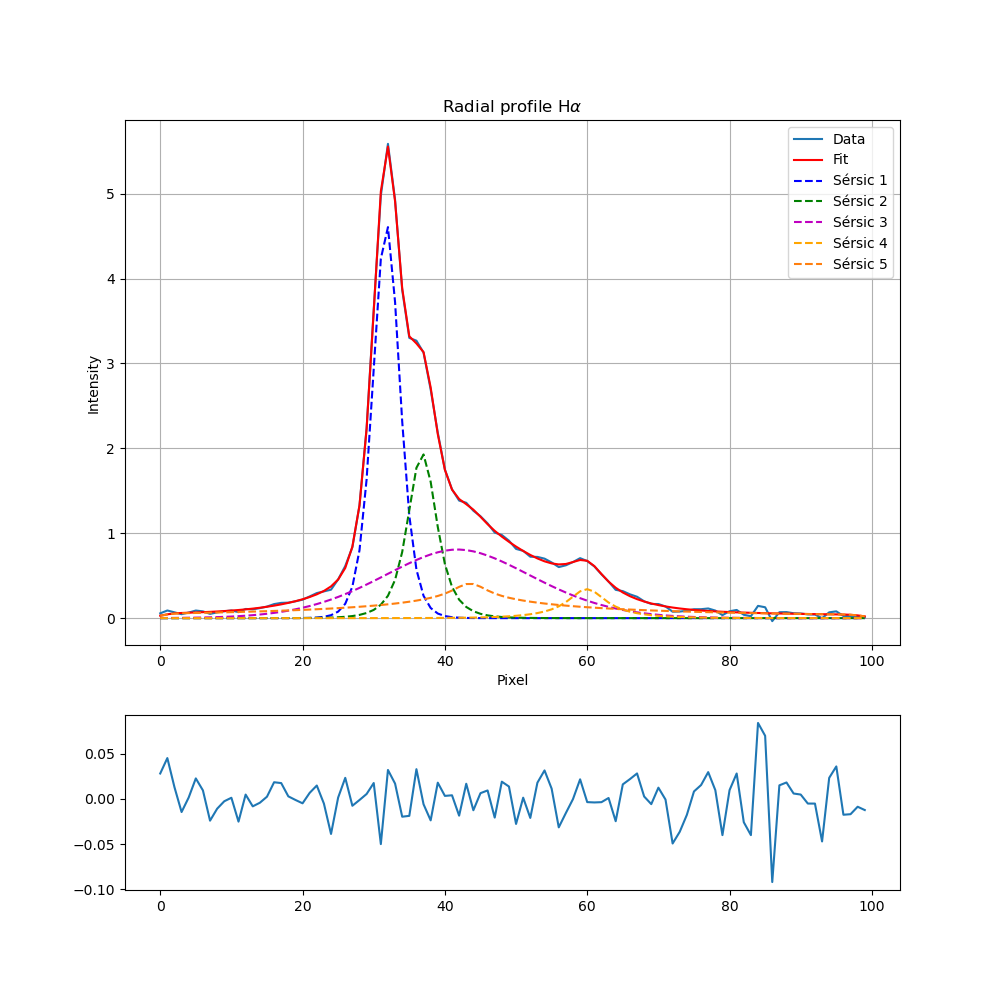

In [19]:
# Plots:
params_curve_5, covariance_5 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params5, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[4], red_chi[4] = save_params(params_curve_5, covariance_5, radial_profile_HA, radial_profile_error_HA, x_axes, 5, line_name="Five", output_prefix="fit")

aic[4] = AIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
bic[4] = BIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
print(aic[4], chi_quadr[4], bic[4], len(params_curve_5))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_5', bbox_inches='tight')

In [20]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (30, 40),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 65),
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 249165.41201578762
differential_evolution step 2: f(x)= 88533.21509386452
differential_evolution step 3: f(x)= 88533.21509386452
differential_evolution step 4: f(x)= 58751.55918884252
differential_evolution step 5: f(x)= 58751.55918884252
differential_evolution step 6: f(x)= 17401.430914761593
differential_evolution step 7: f(x)= 17401.430914761593
differential_evolution step 8: f(x)= 17401.430914761593
differential_evolution step 9: f(x)= 9294.457183016586
differential_evolution step 10: f(x)= 9294.457183016586
differential_evolution step 11: f(x)= 9294.457183016586
differential_evolution step 12: f(x)= 9294.457183016586
differential_evolution step 13: f(x)= 9294.457183016586
differential_evolution step 14: f(x)= 9294.457183016586
differential_evolution step 15: f(x)= 5303.795535699897
differential_evolution step 16: f(x)= 5303.795535699897
differential_evolution step 17: f(x)= 5303.795535699897
differential_evolution step 18: f(x)= 5303.7955356998

Optimize parameters with curve fit:
Sérsic 1: I_e=1.6631, r_e=3.8463, n=0.3412, x_0=34.3888
Sérsic 2: I_e=0.0810, r_e=6.6794, n=3.5156, x_0=31.5394
Sérsic 3: I_e=0.1814, r_e=14.4480, n=0.9120, x_0=45.0963
Sérsic 4: I_e=0.0913, r_e=3.9917, n=0.9831, x_0=59.6417
Sérsic 5: I_e=0.0155, r_e=6.4478, n=0.1000, x_0=41.3803
Sérsic 6: I_e=0.0992, r_e=29.2613, n=0.9387, x_0=41.2173
[4.83754517e-01 7.51130044e-01 1.85217363e-01 1.29329188e+00
 2.49536737e+00 1.17048975e+02 4.69798504e+01 1.77406038e-03
 4.41379624e-01 3.18658334e+01 1.13124132e+00 2.94419549e+00
 1.00779838e-01 5.36734546e+00 8.79176810e-01 4.05742362e-01
 1.39762601e+00 2.50461410e+02 1.12031850e+01 8.17392178e+01
 5.92067810e-01 4.66794125e+01 1.57401551e+00 1.51207631e+01]
2.53522197673511
66.5352219767351 2.53522197673511 113.05930644044932 24


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15272\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15272\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15272\3473308980.py:12: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


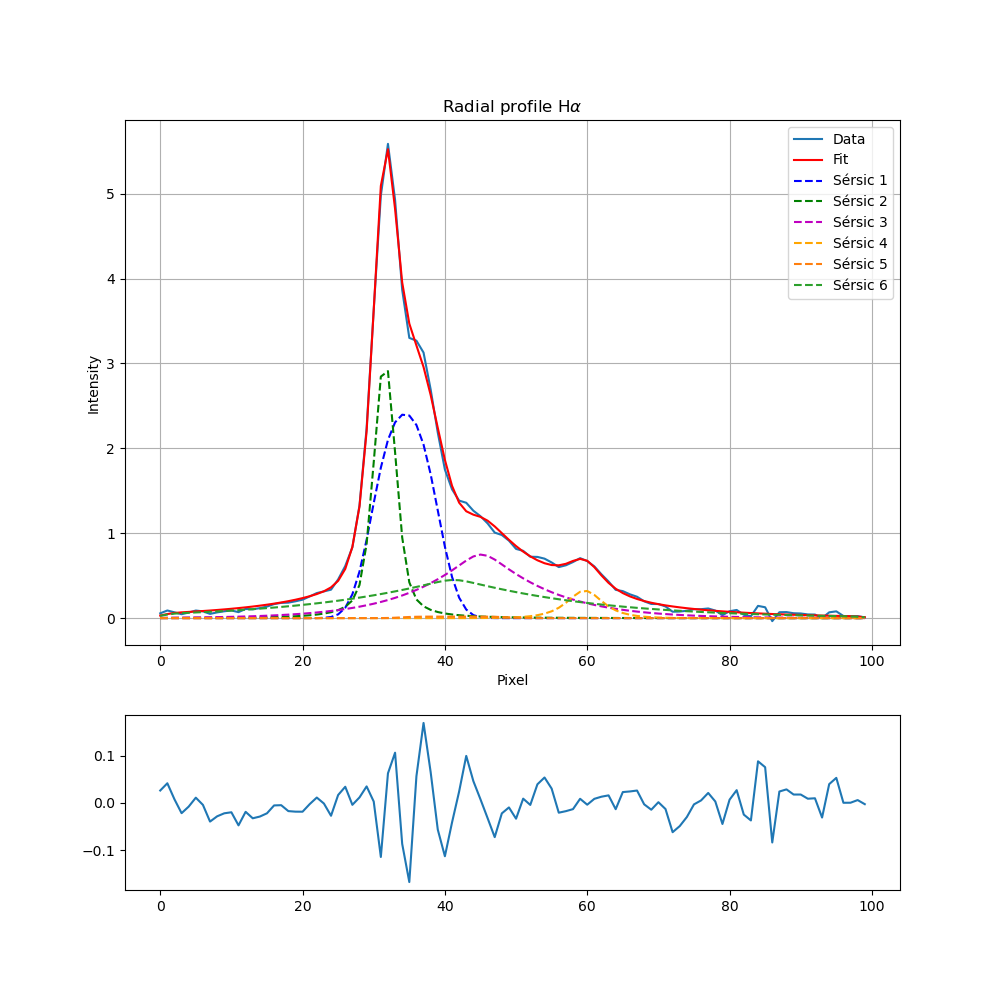

In [21]:
# Plots:
params_curve_6, covariance_6 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params6, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[5], red_chi[5] = save_params(params_curve_6, covariance_6, radial_profile_HA, radial_profile_error_HA, x_axes, 6, line_name="Six", output_prefix="fit")

aic[5] = AIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
bic[5] = BIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_6', bbox_inches='tight')

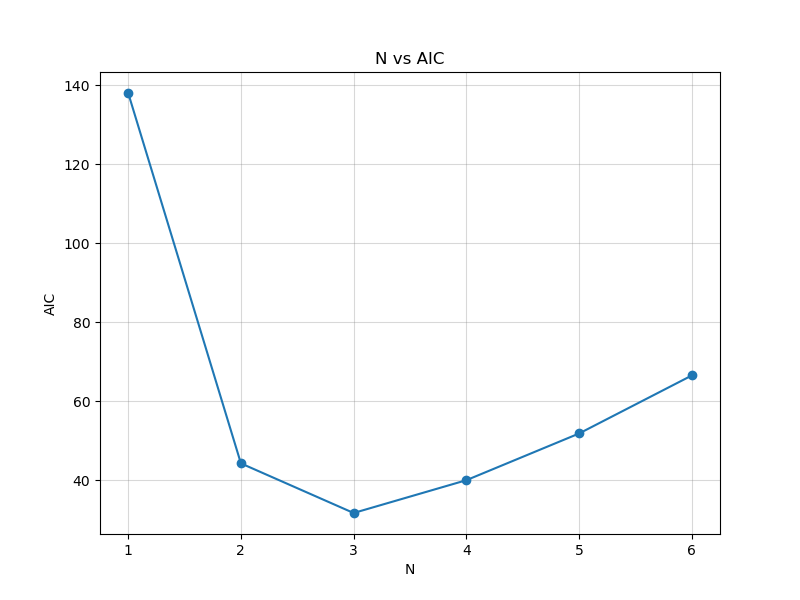

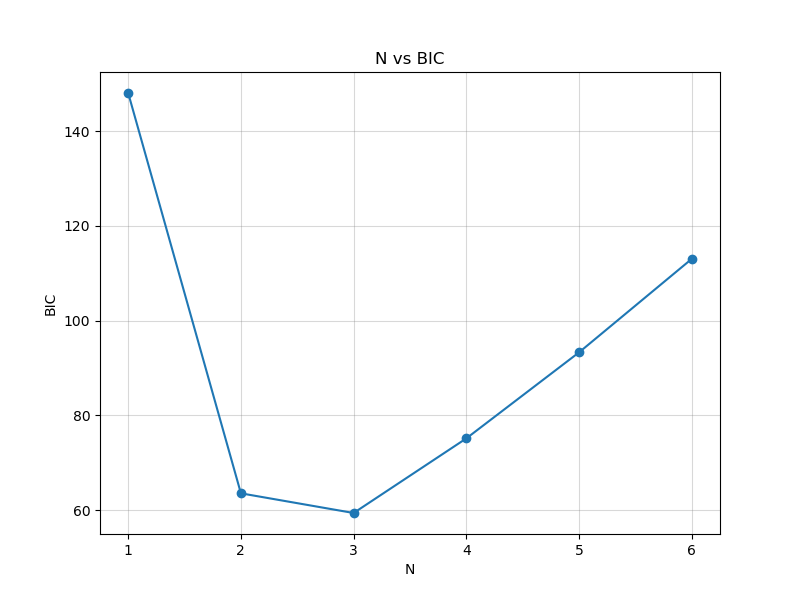

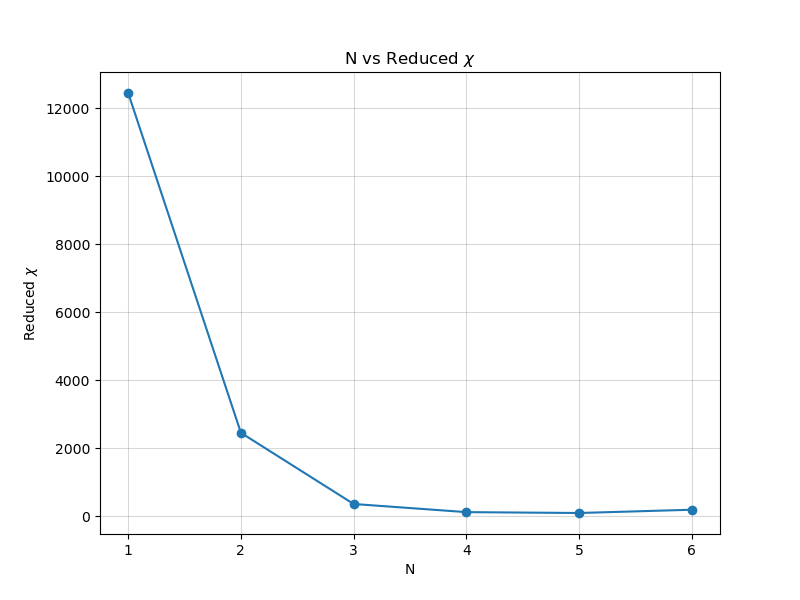

In [22]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6]

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N')

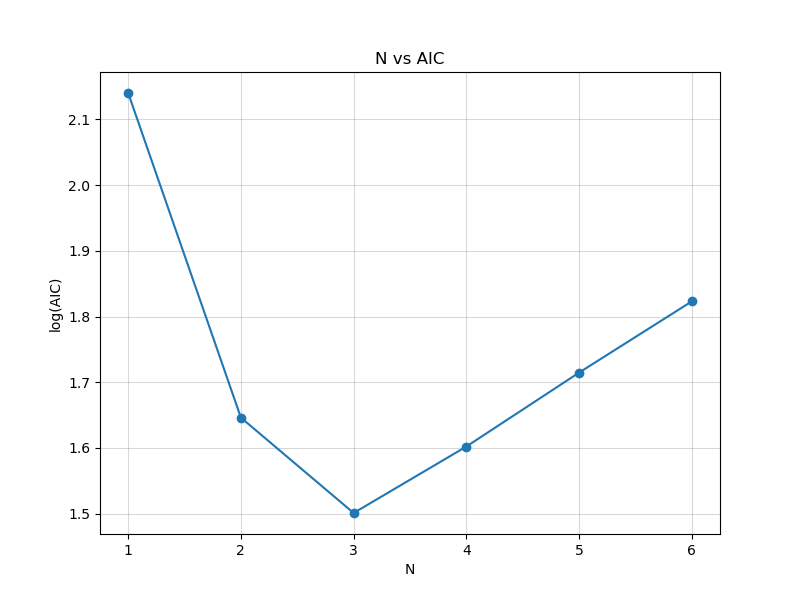

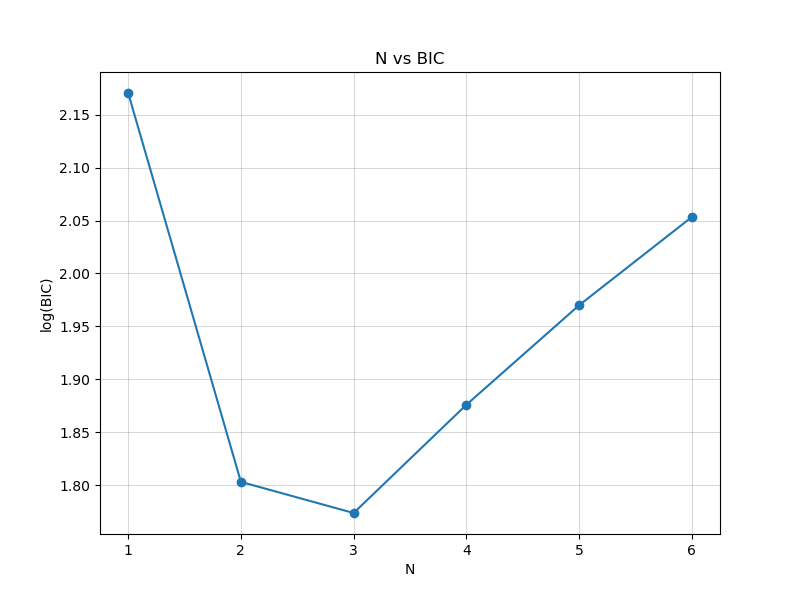

In [23]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log')